In [ ]:
from langchain_core.messages import HumanMessage,SystemMessage # type: ignore
from langchain_community.vectorstores import Chroma # type: ignore
from langchain_groq import ChatGroq # type: ignore
from langchain_core.output_parsers import StrOutputParser # type: ignore
from langchain_ollama import OllamaEmbeddings,ChatOllama,chat_models # type: ignore
from langchain_classic.agents import Agent # type: ignore
from langchain_text_splitters import RecursiveCharacterTextSplitter # type: ignore
from langchain_google_genai import GoogleGenerativeAIEmbeddings # type: ignore
from dotenv import load_dotenv # type: ignore
import os 
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.document_loaders import WebBaseLoader

In [ ]:
print(api_key)

In [ ]:
embed=GoogleGenerativeAIEmbeddings(model="gemini-embedding-001",api_key=api_key)
print(embed.embed_query("test"))


In [ ]:
llm=ChatGoogleGenerativeAI(model="gemini-3-flash-preview",api_key=api_key)
result=llm.invoke("hi")
result.text

In [ ]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

loader=[WebBaseLoader(url) for url in urls]
result=[item for load in loader for item in load] 
print(result)

In [ ]:
%pip install pageindex

# pageindex vectorless Rag pipeline.

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()
page_api_key=os.getenv("PAGE_INDEX_API")
groqapi_key=os.getenv("GROQ_API_KEY")


In [ ]:
from pageindex import PageIndexClient
import pageindex.utils as utils
from langchain_groq import ChatGroq
from groq import Groq

pi_client=PageIndexClient(api_key=page_api_key)
print(pi_client)




In [ ]:
async def call_llm(prompt, model="llama-3.3-70b-versatile",temp=0.0):
    client=Groq(api_key=groqapi_key)
    response=client.chat.completions.create(
        model=model,
        temperature=temp,
        messages=[{"role":"user","content":prompt}]
    )
    return response.choices[0].message.content.strip()

In [ ]:
import os ,requests



pdf_url="https://arxiv.org/pdf/2501.12948.pdf"
pdf_path=os.path.join("data",pdf_url.split('/')[-1])
os.makedirs(os.path.dirname(pdf_path),exist_ok=True)
print(pdf_path)


response=requests.get(pdf_url)

with open(pdf_path,"wb") as f:
    f.write(response.content)

print(f"downloaded pdf url:{pdf_url}")

doc_id=pi_client.submit_document(pdf_path)["doc_id"]
print("document submitted:",doc_id)

In [ ]:
doc_id="pi-cmm8tkj2a07tz0fo98t0xrzho"

In [ ]:
if pi_client.is_retrieval_ready(doc_id):
    tree=pi_client.get_tree(doc_id,node_summary=True)["result"]
    print("simplified tree structured")
    utils.print_tree(tree)
else:
    print("processing doc")

In [ ]:
import json 
query="What is model based rewards and ethics and safety statement?"

tree_without_text=utils.remove_fields(tree.copy(),fields=["text"])
print(tree_without_text)

search_prompt=f"""
you are gven a question and tree structure of document.
each node contains a node_id, title and corresponding summary.

your task is to find all nodes that are likely  to contain the answer to the question.

Question:{query}

Document tree structure:

{json.dumps(tree_without_text,indent=2)}

please reply in the following JSON format:
{{
"thinking": "<you are thinking process on which nodes are relevant question>",
"node_list":["node_id_1", "node_id_2", ..., "node_id_n"]
}}
Directly return the final JSON struture . do not output anything else
"""

tree_search_result=await call_llm(search_prompt)

print(tree_search_result)


In [ ]:
import re 
match=re.search(r"```json\s+(.*?)\s+```", tree_search_result, re.DOTALL)
print(match)
if match:
    json_str=match.group(1)
    try:
        tree_search_result_json = json.loads(json_str)
        print(tree_search_result_json["node_list"])
    except json.JSONDecodeError as e:
        print(f"failed to decoder:{e}")

else:
    tree_search_result_json=json.loads(tree_search_result.strip())



In [ ]:
node_map=utils.create_node_mapping(tree)
print("resoning process")
utils.print_wrapped(tree_search_result_json["thinking"])

print("retrieved nodes")
for node_id in tree_search_result_json["node_list"]:
    node=node_map[node_id]
    print(f"Node ID: {node['node_id']}\t Page: {node['page_index']}\t Title: {node['title']}")

In [ ]:
node_list=tree_search_result_json["node_list"]
print(node_list)

relevant_content='\n\n'.join(node_map[node_id]["text"] for node_id in node_list[:3])


print("reterived context")
utils.print_wrapped(relevant_content[:1000]+'---')

In [ ]:
answer_prompt=f"""
Answer  the question based on the context.

Question:{query}
context:{relevant_content}
provide a clear and concise answe based only on the context provided

"""


answer=await call_llm(answer_prompt)

utils.print_wrapped(answer)

In [ ]:
#self Rag pipeline


from typing import List , TypedDict, Literal
from pydantic import BaseModel , Field
import time
from langchain_community.vectorstores import Chroma
from langchain_community.document_loaders import PyPDFLoader
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph ,START, END 
from dotenv import load_dotenv
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
load_dotenv()



In [ ]:
docs=(
    PyPDFLoader("data/Company_Policies.pdf").load()
    + PyPDFLoader("data/Company_Profile.pdf").load()
    + PyPDFLoader("data/Product_and_Pricing.pdf").load()
)

# for doc in docs:
#     print(doc)

In [ ]:
chunk=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=100).split_documents(docs)

embeddeding=OllamaEmbeddings(model="nomic-embed-text:latest")

vector_Store=Chroma(embedding_function=embeddeding,persist_directory='data')
print(vector_Store)
vector_Store.add_documents(chunk)
# query="how many sick leaves are given to employee"
# result=vector_Store.similarity_search(query=query,k=4)
reteriver=vector_Store.as_retriever(search_type="mmr",search_kwargs={"k":10})
print(reteriver)



In [ ]:
#state graph 
class State(TypedDict):
    question:str
    need_retrieval:bool
    docs:List[Document]
    anw:str





In [ ]:
class ReterivedDecision(BaseModel):
    should_reterived:bool=Field(
        ..., description="True if external document are needed to answer reliably else False"
    )


decide_reterived_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",
         "you decide whether retrieval needed.\n"
         "return JSON that matches this schema:\n"
         "{{'should_reterived':boolean}}\n\n"
         "Guidlines:\n"
         "-should_reterived=True if answering requires specific facts , citation info likely not in the model"
         "-should_retrieved=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
        "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

llm=ChatOllama(model="gemma2:2b",temperature=0.0)
should_retrieve_llm = llm.with_structured_output(ReterivedDecision)

print(should_retrieve_llm)

def decide_retrieval(state:"State"):
    decision: ReterivedDecision = should_retrieve_llm.invoke(
        decide_reterived_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_reterived}



direct_generation_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",
         "answer the question using general knowledge\n"
         "do not assume external document out this specific source"),
         ("human","{question}"),
    ]
)


def generate_direct(state:State):
    ans=llm.invoke(
        direct_generation_prompt.from_messages(
            question=state["question"]
        )
    )
    return {
        "answer":ans.content
    }

         

In [ ]:
def reterive(state:State):
    return {"docs":reteriver.invoke(state["question"])}
def route_after_decide(state:State)->Literal["generate_direct","reterive"]:
    if state["need_retrieval"]:
        return "reterive"
    else:
        return "generate_direct"
    

In [ ]:
G=StateGraph(State)

#nodes

G.add_node("decide_retrieval",decide_retrieval)
G.add_node("generate_direct",generate_direct)
G.add_node("reterive",reterive)


#add Edges
G.add_edge(START,"decide_retrieval")

G.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
       "generate_direct" :"generate_direct",

       "reterive" :"reterive"
    }
)
G.add_edge("generate_direct",END)
G.add_edge("reterive",END)


app=G.compile()
app

In [ ]:
result=app.invoke(
    {
"question":"what is the terms and conditioned applied to leaves of employee",
"need_retrieval":True,
"docs":[],
"anw":" "

    }
)
result["anw"]

In [1]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
#from .autonotebook import tqdm as notebook_tqdm
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
load_dotenv()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
docs = (
     PyPDFLoader("data/Company_Policies.pdf").load()
    + PyPDFLoader("data/Company_Profile.pdf").load()
    + PyPDFLoader("data/Product_and_Pricing.pdf").load())

In [3]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [4]:
embeddings = OllamaEmbeddings(model="nomic-embed-text:latest")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})
print(retriever)

tags=['FAISS', 'OllamaEmbeddings'] vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x12e624d60> search_kwargs={'k': 4}


In [ ]:
# git checkout master
# git pull origin master
# git merge test
# git push origin master


In [5]:
llm=ChatOllama(model="gemma2:2b")

In [6]:
class State(TypedDict):
    question:str
    need_reterival:bool
    docs:List[Document]
    relevant_docs:List[Document]
    answer:str



class ReterivDecision(BaseModel):
    should_reterive:bool=Field(...,description="True if external documents are needed to answer reliably, else false")


decide_retrival_prompt=ChatPromptTemplate.from_messages(

    [
        ("system",
         "decide wheather reterival is needed .\n"
         "return JSON that matches this schema:\n"
         "{{should_reterive:boolean}}\n\n"
         "Guidelines:\n"
         "- should_reterive=True if answer requires specific facts , citation"
         "-should_reterive=False for general explantion , defination or reasons"),
         ("human","Question:{question}"),
    ]
)

should_reteriv_llm=llm.with_structured_output(ReterivDecision)

#chain=should_reteriv_llm|decide_retrival_prompt|StrOutputParser()


def decide_reterival(state:"State"):
    decision:ReterivDecision=should_reteriv_llm.invoke(decide_retrival_prompt.format_messages(question=state["question"]))
    return {"need_reterival":decision.should_reterive}

In [7]:
direct_generation_prompt=ChatPromptTemplate.from_messages([

    ("system",
     "Answer the question only using the general knowledge"
     "do not assume source of any extenal documents"
     "if you are unsure about the specific question then simply reply i do not have that knowledge "),
     ("human","question:{question}")

])

def generate_direct(state:State):
    result=llm.invoke(direct_generation_prompt.format_messages(question=state["question"]))
    return {
        "result":result.content
    }

In [8]:
def retrive(state:State):
    return {"docs":retriever.invoke(state["question"])}

In [9]:
class RelevanceDecision(BaseModel):
    is_relevant:bool=Field(...,description="Ture if the docuement helps the question else false")


is_relevant_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",
         "you are judging document relevance.\n"
         "Return Json that matches this schema"
         
         "{{'is_relevant':boolean}}\n\n"
         "document is useful if it contain information that is useful to give the answer"),
         ("human","Question:\n{question}\n\n Document:\n{document}"),
    ]
)


relevance_llm=llm.with_structured_output(RelevanceDecision)

def is_relevant(state:State):
    relevant_docs:List[Document]=[]

    for doc in state["docs"]:
        Decision:RelevanceDecision=relevance_llm.invoke(is_relevant_prompt.format_messages(
            question=state["question"],
            document=doc.page_content
        ))
        if Decision.is_relevant:
            relevant_docs.append(doc)
    return {"relevant_docs":relevant_docs}

In [10]:
def route_after_decide(state:State)->Literal["generate_direct","retrive"]:
    if state["need_reterival"]:
        return "retrive"
    else:
        return "generate_direct"

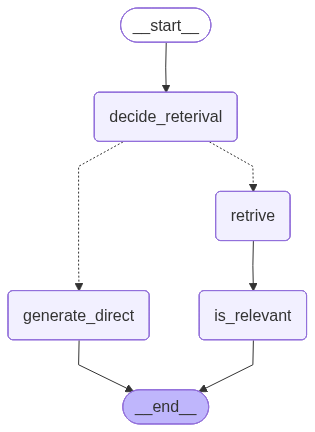

In [11]:
Graph=StateGraph(State)
Graph.add_node("decide_reterival",decide_reterival)
Graph.add_node("generate_direct",generate_direct)
Graph.add_node("retrive",retrive)
Graph.add_node("is_relevant",is_relevant)

Graph.add_edge(START,"decide_reterival")
Graph.add_conditional_edges(
    "decide_reterival",
    route_after_decide,
    {
        "generate_direct":"generate_direct",
        "retrive":"retrive"
    },
)
Graph.add_edge("generate_direct",END)
Graph.add_edge("retrive","is_relevant")
Graph.add_edge("is_relevant",END)

app=Graph.compile()

app

In [12]:
result = app.invoke(
    {
        "question": "Who is the CEO of NexaAI",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])

: 